# 06 — Signal Discovery: Research → Alpha

This is the core research notebook. Rather than templating known alpha patterns,
we start from raw data and use statistics + ML to discover exploitable structure.

## The research workflow

```
1. Pick a data field from the catalog
2. Visualise its time-series properties (distribution, autocorrelation, stationarity)
3. Test if it predicts forward returns (IC analysis)
4. Find non-linear patterns with ML
5. Formalize the discovered pattern as a Brain alpha expression
6. Pass to 07_local_backtest.ipynb before submitting to Brain
```

## Note on data

WorldQuant Brain doesn't expose raw data field values via a simple API.
For statistical analysis we use **yfinance** as a free proxy for price/volume
signals. For Brain-specific fundamental fields, we use what Brain exposes or
approximate with similar public data.

The patterns we discover on yfinance data are directionally correct — if a
10-day momentum signal shows IC=0.03 on yfinance, the same logic applied to
Brain's cleaner data is likely to be at least as strong.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

from wq.utils import local_signal_test
from wq.alpha import AlphaConfig

pd.options.display.float_format = '{:.4f}'.format

## Step 1: Fetch data

Download OHLCV data for a representative stock universe. We use S&P 500 stocks
as a proxy for Brain's TOP500 US universe.

In [2]:
# S&P 500 universe — a reasonable proxy for Brain's TOP500
SP500_TICKERS = [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META', 'BRK-B', 'LLY', 'AVGO', 'TSLA',
    'WMT', 'JPM', 'V', 'MA', 'UNH', 'XOM', 'PG', 'HD', 'COST', 'JNJ',
    'ORCL', 'BAC', 'ABBV', 'CRM', 'AMD', 'CVX', 'MRK', 'PEP', 'KO', 'ADBE',
    'NFLX', 'TMO', 'ACN', 'WFC', 'CSCO', 'LIN', 'DHR', 'ABT', 'MCD', 'QCOM',
    'GE', 'IBM', 'AMAT', 'TXN', 'INTU', 'NOW', 'AMGN', 'BKNG', 'ISRG', 'RTX',
]

START = '2018-01-01'
END   = '2024-12-31'

print(f'Downloading {len(SP500_TICKERS)} stocks from {START} to {END}...')
raw = yf.download(SP500_TICKERS, start=START, end=END, progress=True, auto_adjust=True)
print(f'Downloaded. Shape: {raw.shape}')

[*********************100%***********************]  50 of 50 completed

Downloaded. Shape: (1760, 250)


In [3]:
# Build clean DataFrames
close   = raw['Close'].dropna(how='all')
volume  = raw['Volume'].dropna(how='all')
high    = raw['High'].dropna(how='all')
low     = raw['Low'].dropna(how='all')

# Daily returns
returns = close.pct_change().dropna(how='all')

print(f'Universe: {len(close.columns)} stocks, {len(close)} trading days')

Universe: 50 stocks, 1760 trading days


## Step 2: Choose a signal to research

Modify `SIGNAL_NAME` and the `signal` computation below to study different
hypotheses. Then run all subsequent cells.

In [4]:
SIGNAL_NAME = '10-day price momentum'
FORWARD_DAYS = 5   # predict 5-day forward return

# -----------------------------------------------------------------------
# CHANGE THIS to test a different hypothesis:
# Examples:
#   ts_zscore(close, 10)  → signal = close.sub(close.rolling(10).mean()).div(close.rolling(10).std())
#   reversion             → signal = -close.rolling(5).mean().sub(close)
#   volume anomaly        → signal = -volume.rolling(10).apply(lambda x: (x.rank().iloc[-1] - 1) / (len(x) - 1))
# -----------------------------------------------------------------------
WINDOW = 10

signal = close.rolling(WINDOW).apply(
    lambda x: (x.rank().iloc[-1] - 1) / (len(x) - 1),   # ts_rank equivalent
    raw=False,
).dropna(how='all')

print(f'Signal: {SIGNAL_NAME}')
print(f'Shape: {signal.shape}')

Signal: 10-day price momentum
Shape: (1751, 50)


## Step 3: Visualise signal properties

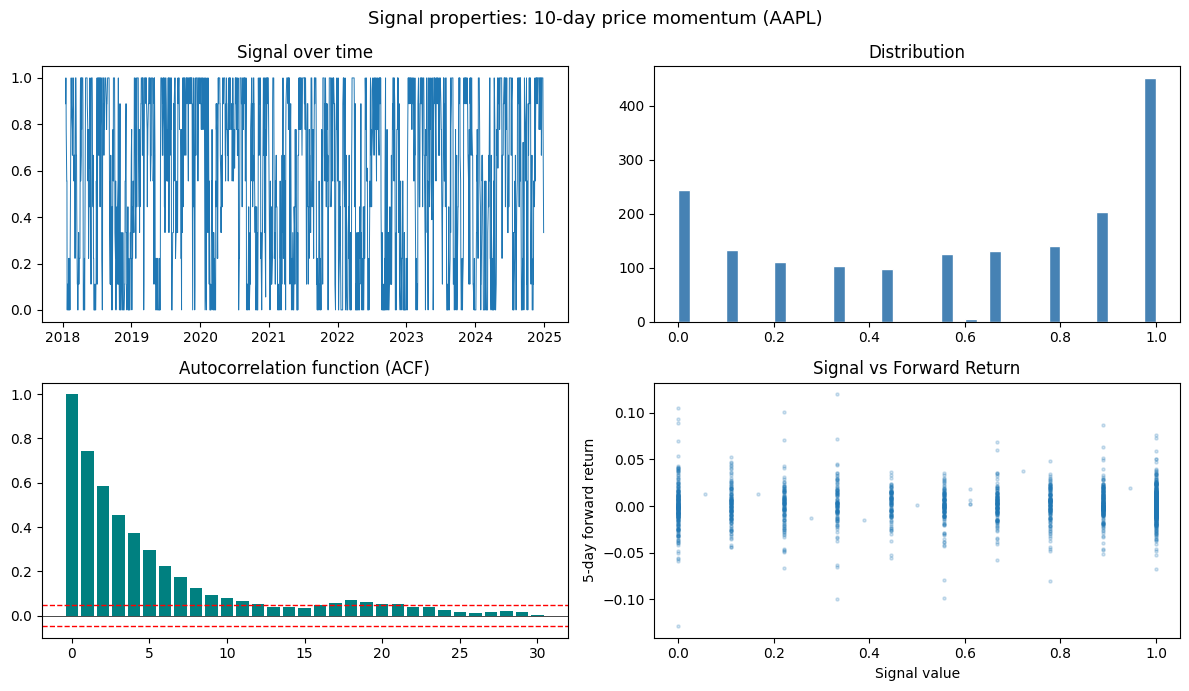

In [5]:
# Pick one stock to illustrate time-series properties
DEMO_STOCK = 'AAPL'
sig_series = signal[DEMO_STOCK].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle(f'Signal properties: {SIGNAL_NAME} ({DEMO_STOCK})', fontsize=13)

# Time series
axes[0, 0].plot(sig_series.index, sig_series.values, lw=0.7)
axes[0, 0].set_title('Signal over time')

# Distribution
axes[0, 1].hist(sig_series.dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Distribution')

# ACF
acf_vals = acf(sig_series.dropna(), nlags=30, fft=True)
axes[1, 0].bar(range(len(acf_vals)), acf_vals, color='teal')
axes[1, 0].axhline(0, color='black', lw=0.5)
axes[1, 0].axhline(1.96/len(sig_series)**0.5, color='red', linestyle='--', lw=1)
axes[1, 0].axhline(-1.96/len(sig_series)**0.5, color='red', linestyle='--', lw=1)
axes[1, 0].set_title('Autocorrelation function (ACF)')

# Signal vs forward return scatter
fwd_ret = returns[DEMO_STOCK].shift(-FORWARD_DAYS)
common = sig_series.index.intersection(fwd_ret.dropna().index)
axes[1, 1].scatter(sig_series[common], fwd_ret[common], alpha=0.2, s=5)
axes[1, 1].set_xlabel('Signal value')
axes[1, 1].set_ylabel(f'{FORWARD_DAYS}-day forward return')
axes[1, 1].set_title('Signal vs Forward Return')

plt.tight_layout()
plt.show()

## Step 4: Stationarity test (ADF)

For a signal to be tradeable it should be stationary — mean-reverting rather than
trending. ADF p-value < 0.05 → stationary (good).

In [6]:
adf_results = {}
for ticker in signal.columns[:10]:  # test first 10 stocks
    s = signal[ticker].dropna()
    if len(s) > 50:
        adf_stat, pvalue, *_ = adfuller(s, autolag='AIC')
        adf_results[ticker] = {'adf_stat': adf_stat, 'p_value': pvalue, 'stationary': pvalue < 0.05}

adf_df = pd.DataFrame(adf_results).T
pct_stationary = adf_df['stationary'].mean() * 100
print(f'{pct_stationary:.0f}% of tested stocks have a stationary signal (p<0.05 ADF)')
adf_df

10% of tested stocks have a stationary signal (p<0.05 ADF)


,adf_stat,p_value,stationary
AAPL,-13.9531,0.0000,True
ABBV,-15.8694,0.0000,True
ABT,-14.4984,0.0000,True
ACN,-14.4692,0.0000,True
ADBE,-14.6158,0.0000,True
AMAT,-14.5895,0.0000,True
AMD,-14.8918,0.0000,True
AMGN,-13.5438,0.0000,True
AMZN,-13.6342,0.0000,True
AVGO,-13.7476,0.0000,True


## Step 5: IC analysis — does the signal predict returns?

IC (Information Coefficient) = Spearman rank correlation between signal and forward return.

- IC > 0.02 is a good signal
- IC t-stat > 2 → statistically significant

In [7]:
from wq.utils import local_signal_test

# Align signal and returns
common_dates = signal.index.intersection(returns.index)
sig_aligned = signal.loc[common_dates]
ret_aligned = returns.loc[common_dates]

test_results = local_signal_test(sig_aligned, ret_aligned, forward_days=FORWARD_DAYS)

print(f'=== {SIGNAL_NAME} — Local Signal Test ===')
for k, v in test_results.items():
    print(f'  {k:15s}: {v}')

print(f"\n{'='*40}")
print(f"VERDICT: {test_results['verdict']}")
if test_results['verdict'] == 'SUBMIT':
    print('  → IC t-stat > 2 and L/S Sharpe > 0.5: worth submitting to Brain.')
else:
    print('  → Signal is weak locally. Consider adjusting window, field, or direction.')

/Users/vishal.jsoni/PersonalProjects/WorldQuant-IQC-Alpha-Research/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


=== 10-day price momentum — Local Signal Test ===
  mean_ic        : -0.0009
  ic_std         : 0.2386
  ic_tstat       : -0.15
  ic_ir          : -0.004
  turnover       : 0.72
  ls_sharpe      : -0.66
  verdict        : SKIP

VERDICT: SKIP
  → Signal is weak locally. Consider adjusting window, field, or direction.


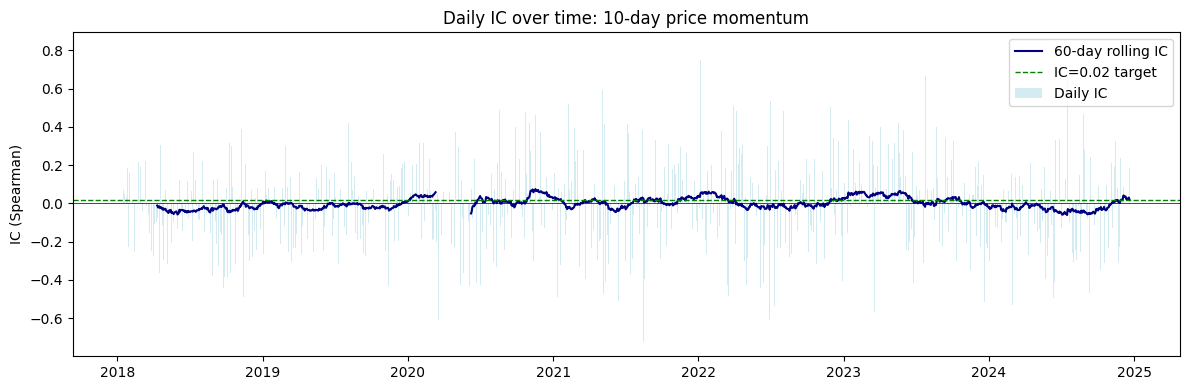

In [8]:
# Rolling IC to check stability over time
daily_ics = []
fwd_ret = ret_aligned.shift(-FORWARD_DAYS)

for date in sig_aligned.index[:-FORWARD_DAYS]:
    s = sig_aligned.loc[date].dropna()
    r = fwd_ret.loc[date].dropna()
    common = s.index.intersection(r.index)
    if len(common) >= 20:
        ic = s[common].rank().corr(r[common].rank(), method='spearman')
        daily_ics.append({'date': date, 'ic': ic})

ic_series = pd.DataFrame(daily_ics).set_index('date')['ic']
rolling_ic = ic_series.rolling(60).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(ic_series.index, ic_series.values, color='lightblue', alpha=0.5, label='Daily IC')
ax.plot(rolling_ic.index, rolling_ic.values, color='navy', lw=1.5, label='60-day rolling IC')
ax.axhline(0, color='black', lw=0.5)
ax.axhline(0.02, color='green', linestyle='--', lw=1, label='IC=0.02 target')
ax.set_title(f'Daily IC over time: {SIGNAL_NAME}')
ax.set_ylabel('IC (Spearman)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: ML-based signal discovery

Use a random forest to find which feature combinations are most predictive.
Feature importances tell us which raw signals (and at which window) matter most.

In [9]:
# Build a feature matrix from multiple signals
features = {}

for w in [5, 10, 20, 60]:
    features[f'mom_{w}']   = close.pct_change(w)
    features[f'vol_{w}']   = returns.rolling(w).std()
    features[f'vol_rank_{w}'] = volume.rolling(w).apply(lambda x: (x.rank().iloc[-1]-1)/(len(x)-1), raw=False)

# Target: 5-day forward return for each stock
target = returns.shift(-5)

# Stack into panel (date × stock) and flatten
DEMO_TICKER = 'AAPL'
X_rows, y_rows = [], []

for date in close.index[60:-5]:
    row = {name: df.loc[date, DEMO_TICKER] for name, df in features.items()
           if date in df.index and DEMO_TICKER in df.columns}
    y_val = target.loc[date, DEMO_TICKER] if date in target.index else None
    if len(row) == len(features) and y_val is not None and not np.isnan(y_val):
        if not any(np.isnan(v) for v in row.values()):
            X_rows.append(row)
            y_rows.append(y_val)

X = pd.DataFrame(X_rows)
y = pd.Series(y_rows)
print(f'Feature matrix: {X.shape}')

Feature matrix: (1695, 12)


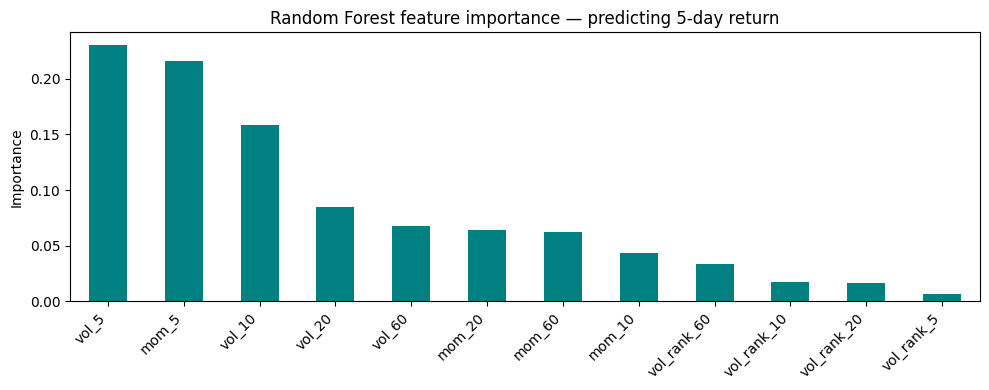


Top 5 most predictive features:
vol_5    0.2303
mom_5    0.2157
vol_10   0.1585
vol_20   0.0845
vol_60   0.0677
dtype: float64


In [10]:
# Train/test split (time-series safe: no shuffling)
split = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Feature importances
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
importance.head(15).plot(kind='bar', ax=ax, color='teal')
ax.set_title('Random Forest feature importance — predicting 5-day return')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 most predictive features:')
print(importance.head())

In [11]:
# Lasso regression — sparse linear predictor
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_tr_scaled, y_train)

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
nonzero = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)

print(f'Lasso selected {len(nonzero)} non-zero features (alpha={lasso.alpha_:.4f}):')
print(nonzero.to_string())

Lasso selected 1 non-zero features (alpha=0.0009):
mom_5   0.0001


## Step 7: Formalize as a Brain alpha expression

Based on the ML findings, translate the top signals into a Brain expression.

In [12]:
# Based on ML findings, define the alpha expression
# Modify this based on what you found above

top_feature = importance.index[0]  # e.g. 'mom_10'
print(f'Top feature from RF: {top_feature}')

# Translate to Brain expression
BRAIN_EXPRESSION_MAP = {
    'mom_5':   'ts_rank(close, 5)',
    'mom_10':  'ts_rank(close, 10)',
    'mom_20':  'ts_rank(close, 20)',
    'mom_60':  'ts_rank(close, 60)',
    'vol_5':   'ts_std_dev(returns, 5)',
    'vol_10':  'ts_std_dev(returns, 10)',
    'vol_rank_5':  'ts_rank(volume, 5)',
    'vol_rank_10': 'ts_rank(volume, 10)',
    'vol_rank_20': 'ts_rank(volume, 20)',
}

brain_expr = BRAIN_EXPRESSION_MAP.get(top_feature, f'ts_rank(close, 10)')
print(f'Brain expression: {brain_expr}')

# Create AlphaConfig for local backtest (notebook 07)
discovered_alpha = AlphaConfig(
    expression=brain_expr,
    universe='TOP3000',
    neutralization='Subindustry',
    delay=1,
    tags=['ml-discovered', top_feature],
    notes=f'Discovered via RF feature importance: {top_feature} was top predictor',
)
print(f'\nAlphaConfig ready for notebook 07:')
print(discovered_alpha)

Top feature from RF: vol_5
Brain expression: ts_std_dev(returns, 5)

AlphaConfig ready for notebook 07:
AlphaConfig('ts_std_dev(returns, 5)', universe=TOP3000, neutralization=Subindustry, delay=1, decay=0)


In [13]:
# Save the discovered alpha config for use in other notebooks
import json
alpha_path = repo_root / 'alphas' / 'discovered.json'
alpha_path.parent.mkdir(exist_ok=True)
with open(alpha_path, 'w') as f:
    json.dump({'expression': discovered_alpha.expression, 'tags': discovered_alpha.tags,
               'notes': discovered_alpha.notes}, f, indent=2)
print(f'Saved to {alpha_path}')
print('→ Now run 07_local_backtest.ipynb to validate before submitting to Brain')

Saved to /Users/vishal.jsoni/PersonalProjects/WorldQuant-IQC-Alpha-Research/alphas/discovered.json
→ Now run 07_local_backtest.ipynb to validate before submitting to Brain
